<a href="https://colab.research.google.com/github/huanbv/BVU.CaoHoc.BuiVanHuan-XLA/blob/main/BVU_CaoHoc_BuiVanHuan_XLA_BaiTap_28_06_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**1. Đọc và hiển thị ảnh**

Mô tả: Lấy ảnh trực tiếp về, sau đó làm ... cần chuyển về các điểm ảnh bằng imdecode.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


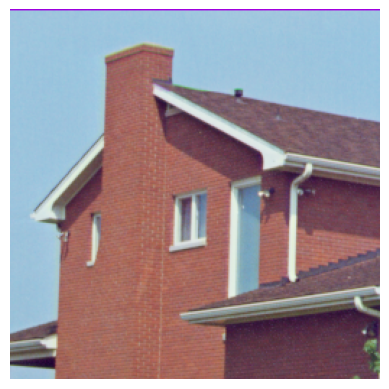

In [ ]:
import cv2
import matplotlib.pyplot as plt

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Đường dẫn tới file ảnh trong Drive
image_path = '/content/drive/MyDrive/Colab Notebooks/misc/4.1.05.tiff'

# Đọc ảnh bằng OpenCV
img = cv2.imread(image_path, cv2.IMREAD_COLOR)

# Hiển thị ảnh (chuyển sang RGB để màu chuẩn)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
#cv2.cvtColor: Dùng để chuyển đổi hệ màu của ảnh
#plt.imshow() Là hàm hiển thị ảnh trong matplotlib. Nhận một mảng số (numpy array) và hiển thị như hình ảnh. Mặc định coi dữ liệu ảnh theo hệ màu RGB.
# plt.imshow(img) # có thể bị lệch màu
plt.axis("off")
plt.show()

### Giải thích:
#- `cv2.cvtColor`: chuyển đổi hệ màu của ảnh (BGR → RGB, BGR → Gray, v.v.)
#- `plt.imshow`: hiển thị ảnh trong notebook. Mặc định matplotlib dùng RGB.
#- Vì OpenCV đọc ảnh theo BGR nên cần đổi sang RGB để hiển thị đúng màu.



**2. Chuyển đổi sang ảnh xám**

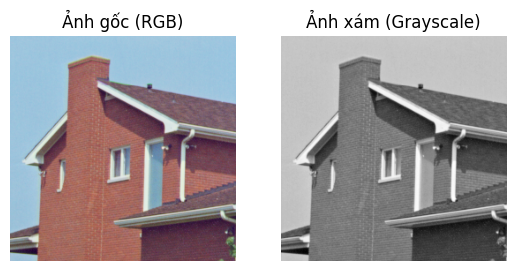

In [ ]:
import cv2
import matplotlib.pyplot as plt
from google.colab import drive

# Đọc ảnh bằng OpenCV (BGR)
img = cv2.imread(image_path, cv2.IMREAD_COLOR)

# Chuyển sang ảnh xám
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Hiển thị ảnh gốc (màu chuẩn)
plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Ảnh gốc (RGB)")
plt.axis("off")

# Hiển thị ảnh xám
plt.subplot(1, 2, 2)
plt.imshow(gray, cmap="gray")
plt.title("Ảnh xám (Grayscale)")
plt.axis("off")

plt.show()


**3. Tách kênh màu**

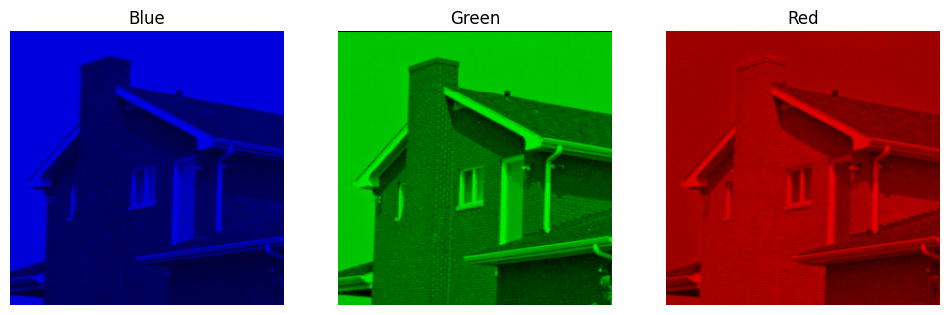

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Tách kênh
b, g, r = cv2.split(img)

# Tạo ảnh màu cho từng kênh
zeros = np.zeros_like(b)
blue_img  = cv2.merge([b, zeros, zeros])
green_img = cv2.merge([zeros, g, zeros])
red_img   = cv2.merge([zeros, zeros, r])

# Hiển thị
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(cv2.cvtColor(blue_img, cv2.COLOR_BGR2RGB))
plt.title("Blue")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(cv2.cvtColor(green_img, cv2.COLOR_BGR2RGB))
plt.title("Green")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(cv2.cvtColor(red_img, cv2.COLOR_BGR2RGB))
plt.title("Red")
plt.axis("off")

plt.show()


**4. Nhị phân hóa ảnh (Thresholding)**

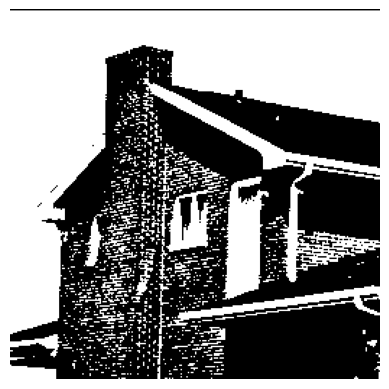

In [ ]:
_, thresh = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY)
#threshold chuyển hình ảnh qua hệ nhị phân. điếm xám từ 127 - 255.
#Ngưỡng điểm ảnh, có thể nâng lên, nếu ảnh của mình thiếu tối hoặc quá sáng.
plt.imshow(thresh, cmap="gray")
plt.axis("off")
plt.show()


**5. Phép toán logic (AND, XOR)**

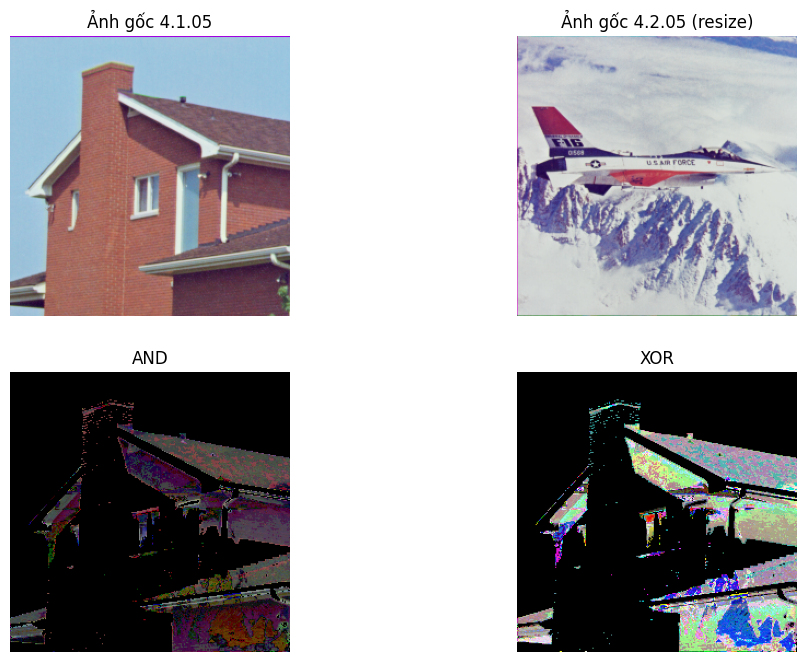

In [ ]:
import cv2
import matplotlib.pyplot as plt
from google.colab import drive

# Đường dẫn tới 2 ảnh
path1 = '/content/drive/MyDrive/Colab Notebooks/misc/4.1.05.tiff'
path2 = '/content/drive/MyDrive/Colab Notebooks/misc/4.2.05.tiff'

# Đọc ảnh bằng OpenCV (BGR)
img1 = cv2.imread(path1, cv2.IMREAD_COLOR)
img2 = cv2.imread(path2, cv2.IMREAD_COLOR)

# Resize img2 về cùng kích thước với img1
img2_resized = cv2.resize(img2, (img1.shape[1], img1.shape[0]))

# Tạo mask đơn giản trên ảnh thứ nhất
mask = cv2.inRange(img1, (0,0,0), (150,150,150))

# Thực hiện AND và XOR giữa hai ảnh với cùng mask
and_img = cv2.bitwise_and(img1, img2_resized, mask=mask)
xor_img = cv2.bitwise_xor(img1, img2_resized, mask=mask)

# Hiển thị cả hai ảnh gốc và kết quả
plt.figure(figsize=(12,8))

plt.subplot(2,2,1)
plt.imshow(cv2.cvtColor(img1, cv2.COLOR_BGR2RGB))
plt.title("Ảnh gốc 4.1.05")
plt.axis("off")

plt.subplot(2,2,2)
plt.imshow(cv2.cvtColor(img2_resized, cv2.COLOR_BGR2RGB))
plt.title("Ảnh gốc 4.2.05 (resize)")
plt.axis("off")

plt.subplot(2,2,3)
plt.imshow(cv2.cvtColor(and_img, cv2.COLOR_BGR2RGB))
plt.title("AND")
plt.axis("off")

plt.subplot(2,2,4)
plt.imshow(cv2.cvtColor(xor_img, cv2.COLOR_BGR2RGB))
plt.title("XOR")
plt.axis("off")

plt.show()


**6. Phép toán cộng, trừ, phóng to, thu nhỏ**

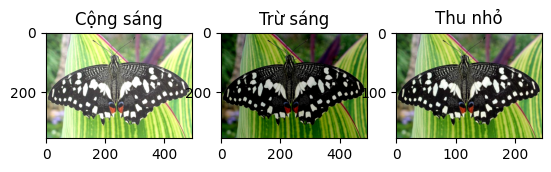

In [ ]:
brighter = cv2.add(img, 50)   # cộng sáng
# Mỗi phần tử +50 khi sử dụng OpenCV, và Max là 255.
darker   = cv2.subtract(img, 50) # trừ sáng
resized  = cv2.resize(img, None, fx=0.5, fy=0.5) # thu nhỏ - Tìm hiểu lại hàm này.
# Từ 400px giảm xuống còn 200px.

plt.subplot(1,3,1); plt.imshow(cv2.cvtColor(brighter, cv2.COLOR_BGR2RGB)); plt.title("Cộng sáng")
plt.subplot(1,3,2); plt.imshow(cv2.cvtColor(darker, cv2.COLOR_BGR2RGB)); plt.title("Trừ sáng")
plt.subplot(1,3,3); plt.imshow(cv2.cvtColor(resized, cv2.COLOR_BGR2RGB)); plt.title("Thu nhỏ")
plt.show()


**7. Điều chỉnh độ sáng, tương phản**

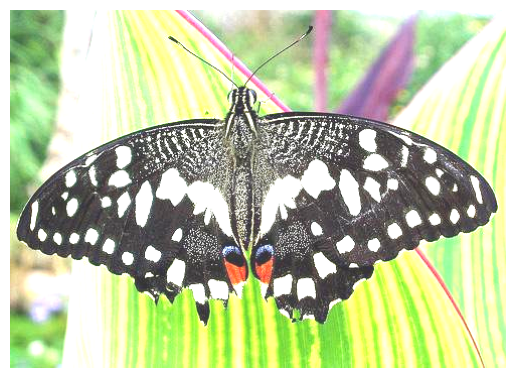

In [ ]:
alpha = 1.5  # hệ số tương phản
beta  = 50   # độ sáng của toàn bộ px của ảnh lên
# 1 ảnh gốc, 1 ảnh chỉnh độ tương phản, 1 hình chỉnh độ sáng và 1 hình chỉnh cả 2 tương phản và độ sáng, sau đó điều chỉnh số 1.5 > 1.7, 50 < 20 xem sự thay đổi, và giải thích cách làm tính toán của điểm ảnh trong mục này.
adjusted = cv2.convertScaleAbs(img, alpha=alpha, beta=beta)
plt.imshow(cv2.cvtColor(adjusted, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()


**8. Lật và xoay ảnh**

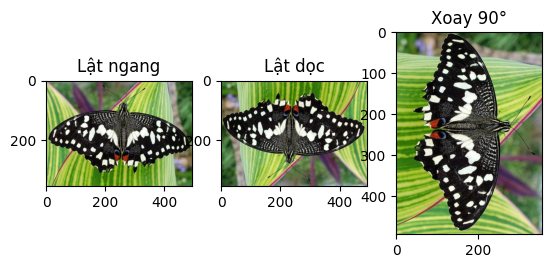

In [ ]:
flip_h = cv2.flip(img, 1)   # lật ngang ảnh từ 0 - 400 bằng điểm ảnh số 1
flip_v = cv2.flip(img, 0)   # lật dọc lấy điểm ảnh .. Tìm hiểu thêm bằng các áp dụng numpy.
rotated = cv2.rotate(img, cv2.ROTATE_90_CLOCKWISE)

plt.subplot(1,3,1); plt.imshow(cv2.cvtColor(flip_h, cv2.COLOR_BGR2RGB)); plt.title("Lật ngang")
plt.subplot(1,3,2); plt.imshow(cv2.cvtColor(flip_v, cv2.COLOR_BGR2RGB)); plt.title("Lật dọc")
plt.subplot(1,3,3); plt.imshow(cv2.cvtColor(rotated, cv2.COLOR_BGR2RGB)); plt.title("Xoay 90°")
plt.show()


**9. Chuyển đổi hệ màu**

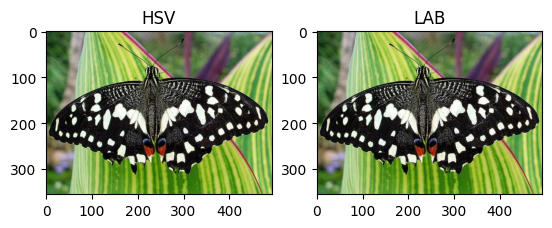

In [ ]:
hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
#Chuyển đổi hệ màu, lấy hình ảnh. RGB + Tự nhiên HSV + Hệ màu máy in CMK. Sau đó lấy hình ảnh của 3 hệ màu chuyển với nhau để so sánh (phân biệt) thì sẽ thấy sự khác nhau.
#Mỗi hệ màu, lấy 1 ảnh làm, sẽ so sánh được.

plt.subplot(1,2,1); plt.imshow(cv2.cvtColor(hsv, cv2.COLOR_HSV2RGB)); plt.title("HSV")
plt.subplot(1,2,2); plt.imshow(cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)); plt.title("LAB")
plt.show()
